# CAA Emotion Direction Geometry

**仮説**: LLMは感情を8つの離散的なカテゴリとして表現しているのではなく、低次元の連続的・線形的な多様体上に感情を表現しており、`joy` や `fear` といったラベルはその多様体上の原型領域（prototype region）に対して人間が後付けしたものに過ぎない。

本ノートブックはその仮説の第一段階として、**CAAベクトルそのものの幾何学的性質**を分析します。

**残差ストリームとの違い**: 残差ストリームからの感情中心点は、文体・語彙・テーマなどの「ソーステキスト成分」を除去するためにソースセンタリング（各ソースで感情方向の平均を引く）が必要。
CAAベクトルは定義上 `mean_n(h_emotion[n] - h_neutral[n])` であり、ソース依存成分が既にキャンセルされた純粋な「感情変化方向」。

**分析内容**:
1. 8感情のCAAベクトルのSVD・参加比率 → 空間は低次元か？
2. 感情間コサイン類似度ヒートマップ → どの感情が近い/遠い？
3. Plutchik輪の検証 → 対立感情ペアは逆方向か？
4. 2D/3D可視化 → 感情の配置は連続的か？
5. レイヤー別の幾何学的構造の変化
6. 強度別CAAベクトルの整合性

**入力**: `activation/emotion_rewrites/caa_emotion_directions.npz` — shape `(8, 3, 6, 4096)` および `caa_pooled` shape `(8, 6, 4096)`

**出力**: `analysis/caa/geometry/`

**対応する既存ノートブック**: `affective_subspace_interpretation.ipynb` (ソースセンタリング不要になった版)


## 0. Setup

In [1]:
from __future__ import annotations

import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.spatial.distance import cosine as cosine_dist
from scipy.spatial import procrustes
from scipy.stats import spearmanr
from sklearn.manifold import MDS
from sklearn.decomposition import PCA

warnings.filterwarnings('ignore')

REPO_ROOT = Path('../..').resolve()
ACT_DIR   = REPO_ROOT / 'activation' / 'emotion_rewrites'
CAA_PATH  = ACT_DIR / 'caa_emotion_directions.npz'
INFO_PATH = ACT_DIR / 'caa_emotion_directions_info.json'
OUT_DIR   = REPO_ROOT / 'analysis' / 'caa' / 'geometry'
OUT_DIR.mkdir(parents=True, exist_ok=True)

PRIMARY_LAYER = 13
AUX_LAYERS    = [10, 16]

sns.set_context('notebook')
sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi': 110, 'savefig.dpi': 150})
print('OUT_DIR =', OUT_DIR)

OUT_DIR = /home/maplesugano/proj/EmotionEngine_v2/analysis/caa/geometry


In [2]:
with open(INFO_PATH) as f:
    INFO = json.load(f)

EMOTION_ORDER   = INFO['emotion_order']    # 8 emotions
INTENSITY_ORDER = INFO['intensity_order']  # ['low','medium','high']
LAYER_INDICES   = INFO['layer_indices']    # [8, 10, 13, 16, 19, 22]
LI_MAP          = {l: i for i, l in enumerate(LAYER_INDICES)}
N_EMO           = len(EMOTION_ORDER)
N_INT           = len(INTENSITY_ORDER)
N_LAY           = len(LAYER_INDICES)

data        = np.load(CAA_PATH)
# caa[e, i, l, :]       : unit-normed, per intensity
# caa_pooled[e, l, :]   : unit-normed, pooled over intensities
# delta_mean[e, i, l, :]: raw (not unit-normed) mean difference
CAA         = data['caa']        # (8, 3, 6, 4096)
CAA_POOLED  = data['caa_pooled'] # (8, 6, 4096)
DELTA_MEAN  = data['delta_mean'] # (8, 3, 6, 4096)  — preserves magnitude

D = CAA.shape[-1]
print(f'caa shape       : {CAA.shape}')
print(f'caa_pooled shape: {CAA_POOLED.shape}')
print(f'delta_mean shape: {DELTA_MEAN.shape}')
print(f'Emotions: {EMOTION_ORDER}')
print(f'Layers  : {LAYER_INDICES}  (primary={PRIMARY_LAYER})')

caa shape       : (8, 3, 6, 4096)
caa_pooled shape: (8, 6, 4096)
delta_mean shape: (8, 3, 6, 4096)
Emotions: ['joy', 'trust', 'fear', 'surprise', 'sadness', 'disgust', 'anger', 'anticipation']
Layers  : [8, 10, 13, 16, 19, 22]  (primary=13)


In [3]:
# ── Helpers ───────────────────────────────────────────────────────────────────

def unit(v: np.ndarray) -> np.ndarray:
    """Unit-normalize vector(s) along last axis."""
    n = np.linalg.norm(v, axis=-1, keepdims=True)
    return v / (n + 1e-12)

def get_pooled(layer: int) -> np.ndarray:
    """Return (N_EMO, D) unit-normed CAA pooled directions at given layer."""
    li = LI_MAP[layer]
    return CAA_POOLED[:, li, :]  # already unit-normed

def get_caa(layer: int) -> np.ndarray:
    """Return (N_EMO, N_INT, D) unit-normed CAA directions at given layer."""
    li = LI_MAP[layer]
    return CAA[:, :, li, :]  # already unit-normed

def cosine_matrix(V: np.ndarray) -> np.ndarray:
    """V: (N, D) unit-normed. Return (N, N) cosine similarity matrix."""
    V_u = unit(V)
    return V_u @ V_u.T

def participation_ratio(singular_values: np.ndarray) -> float:
    """Effective dimensionality: (Σs²)² / Σs⁴  (1=single axis, K=uniform K)."""
    lam = singular_values.astype(np.float64) ** 2
    return float(lam.sum() ** 2 / (lam ** 2).sum())

def svd_of_directions(V: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """SVD of (N_EMO, D) direction matrix."""
    mu  = V.mean(axis=0)
    Vc  = (V - mu).astype(np.float64)
    U, S, Vt = np.linalg.svd(Vc, full_matrices=False)
    return U, S, Vt

print('Helpers defined.')

Helpers defined.


---
## 1. SVD of 8 CAA Directions — 感情空間の次元数

8感情のCAAベクトルを行として並べ、SVDを行うことで「感情変化空間」の固有次元を推定する。
- **参加比率 (participation ratio) ≈ 2–3**: 感情は2–3つの基底軸で説明できる → 離散8軸ではなく連続低次元多様体
- **参加比率 ≈ 8**: 感情は独立した8方向 → 離散カテゴリ

In [4]:
rows = []
for layer in LAYER_INDICES:
    V = get_pooled(layer)           # (8, 4096) unit-normed
    _, S, _ = svd_of_directions(V)
    evr   = (S ** 2) / (S ** 2).sum()
    pr    = participation_ratio(S)
    evr_cumul = np.cumsum(evr)
    rows.append({
        'layer': layer,
        'PR': pr,
        'EVR_PC1': evr[0],
        'EVR_PC2': evr[1],
        'EVR_PC3': evr[2],
        'EVR_PC1-2': evr_cumul[1],
        'EVR_PC1-3': evr_cumul[2],
    })

df_svd = pd.DataFrame(rows).set_index('layer')
print(df_svd.to_string(float_format='{:.4f}'.format))
df_svd.to_csv(OUT_DIR / 'caa_svd_by_layer.csv')

          PR  EVR_PC1  EVR_PC2  EVR_PC3  EVR_PC1-2  EVR_PC1-3
layer                                                        
8        NaN      NaN      NaN      NaN        NaN        NaN
10    3.8749   0.4084   0.2306   0.1543     0.6390     0.7933
13    3.6588   0.4288   0.2409   0.1398     0.6697     0.8094
16    3.4379   0.4480   0.2551   0.1272     0.7031     0.8303
19    3.4206   0.4463   0.2628   0.1257     0.7091     0.8348
22    3.3711   0.4481   0.2696   0.1254     0.7177     0.8431


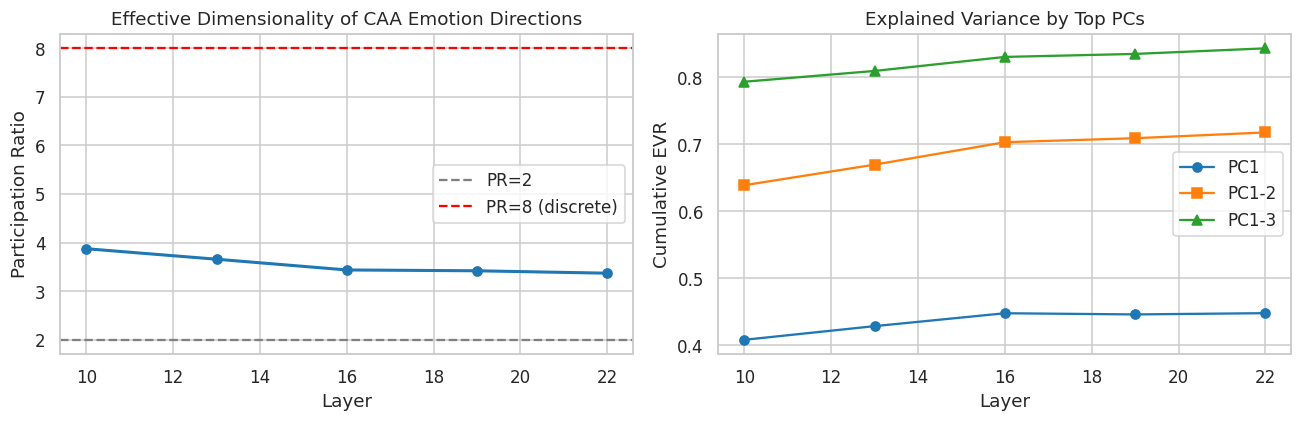

In [5]:
# Layer-wise participation ratio plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(df_svd.index, df_svd['PR'], marker='o', linewidth=2)
axes[0].axhline(2, color='gray', linestyle='--', label='PR=2')
axes[0].axhline(8, color='red',  linestyle='--', label='PR=8 (discrete)')
axes[0].set_xlabel('Layer')
axes[0].set_ylabel('Participation Ratio')
axes[0].set_title('Effective Dimensionality of CAA Emotion Directions')
axes[0].legend()

axes[1].plot(df_svd.index, df_svd['EVR_PC1'],   marker='o', label='PC1')
axes[1].plot(df_svd.index, df_svd['EVR_PC1-2'], marker='s', label='PC1-2')
axes[1].plot(df_svd.index, df_svd['EVR_PC1-3'], marker='^', label='PC1-3')
axes[1].set_xlabel('Layer')
axes[1].set_ylabel('Cumulative EVR')
axes[1].set_title('Explained Variance by Top PCs')
axes[1].legend()

plt.tight_layout()
plt.savefig(OUT_DIR / 'caa_participation_ratio.png', bbox_inches='tight')
plt.show()

---
## 2. 感情間コサイン類似度ヒートマップ

CAAベクトル同士のコサイン類似度を可視化。
- Plutchikの輪では**隣接感情**（joy-trust, fear-surprise など）が正の類似度を持つはず
- **対立感情**（joy-sadness, fear-anger など）が負の類似度を持てば、空間が実際に双極性を持つことを示す

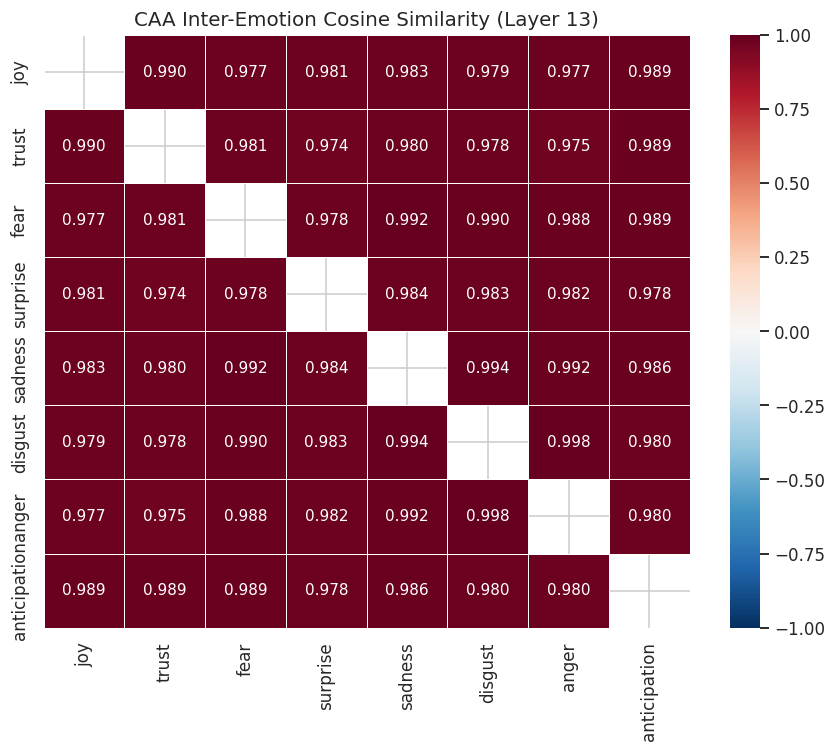

In [6]:
# Primary layer cosine similarity matrix
V_primary = get_pooled(PRIMARY_LAYER)  # (8, 4096)
cos_mat   = cosine_matrix(V_primary)  # (8, 8)

df_cos = pd.DataFrame(cos_mat, index=EMOTION_ORDER, columns=EMOTION_ORDER)

fig, ax = plt.subplots(figsize=(8, 7))
mask = np.eye(N_EMO, dtype=bool)
sns.heatmap(
    df_cos, annot=True, fmt='.3f', cmap='RdBu_r',
    center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=ax, mask=mask,
    annot_kws={'size': 10},
)
ax.set_title(f'CAA Inter-Emotion Cosine Similarity (Layer {PRIMARY_LAYER})', fontsize=13)
plt.tight_layout()
plt.savefig(OUT_DIR / f'caa_cosine_heatmap_L{PRIMARY_LAYER}.png', bbox_inches='tight')
plt.show()

df_cos.to_csv(OUT_DIR / f'caa_cosine_similarity_L{PRIMARY_LAYER}.csv')

---
## 3. Plutchikの輪の検証 — 対立ペアの方向性

Plutchikの感情輪では以下のペアが「対立感情」（wheel上で向かい合う）:
- joy ↔ sadness
- trust ↔ disgust
- fear ↔ anger
- anticipation ↔ surprise

もし感情方向が意味的に組織化されているなら、対立ペアのコサイン類似度は
**非対立ペアより低い（より負に近い）** はず。

In [7]:
# Plutchik opposite pairs
OPPOSITE_PAIRS = [
    ('joy',          'sadness'),
    ('trust',        'disgust'),
    ('fear',         'anger'),
    ('anticipation', 'surprise'),
]
# Adjacent pairs on the wheel (expected to be similar)
ADJACENT_PAIRS = [
    ('joy',          'trust'),
    ('trust',        'fear'),
    ('fear',         'surprise'),
    ('surprise',     'sadness'),
    ('sadness',      'disgust'),
    ('disgust',      'anger'),
    ('anger',        'anticipation'),
    ('anticipation', 'joy'),
]

EMO_POS = {e: i for i, e in enumerate(EMOTION_ORDER)}

rows_pairs = []
for layer in LAYER_INDICES:
    cm = cosine_matrix(get_pooled(layer))
    for a, b in OPPOSITE_PAIRS:
        rows_pairs.append({'layer': layer, 'pair': f'{a}↔{b}',
                            'type': 'opposite', 'cosine': cm[EMO_POS[a], EMO_POS[b]]})
    for a, b in ADJACENT_PAIRS:
        rows_pairs.append({'layer': layer, 'pair': f'{a}↔{b}',
                            'type': 'adjacent', 'cosine': cm[EMO_POS[a], EMO_POS[b]]})

df_pairs = pd.DataFrame(rows_pairs)

# Summary at primary layer
for pair_type in ['opposite', 'adjacent']:
    sub = df_pairs[(df_pairs['layer'] == PRIMARY_LAYER) & (df_pairs['type'] == pair_type)]
    print(f'\n{pair_type.upper()} pairs at layer {PRIMARY_LAYER}:')
    for _, r in sub.iterrows():
        print(f'  {r["pair"]:35s}  cos = {r["cosine"]:+.4f}')
    print(f'  Mean: {sub["cosine"].mean():+.4f}  |  Min: {sub["cosine"].min():+.4f}  |  Max: {sub["cosine"].max():+.4f}')


OPPOSITE pairs at layer 13:
  joy↔sadness                          cos = +0.9829
  trust↔disgust                        cos = +0.9782
  fear↔anger                           cos = +0.9883
  anticipation↔surprise                cos = +0.9775
  Mean: +0.9817  |  Min: +0.9775  |  Max: +0.9883

ADJACENT pairs at layer 13:
  joy↔trust                            cos = +0.9905
  trust↔fear                           cos = +0.9806
  fear↔surprise                        cos = +0.9778
  surprise↔sadness                     cos = +0.9839
  sadness↔disgust                      cos = +0.9943
  disgust↔anger                        cos = +0.9978
  anger↔anticipation                   cos = +0.9795
  anticipation↔joy                     cos = +0.9895
  Mean: +0.9867  |  Min: +0.9778  |  Max: +0.9978


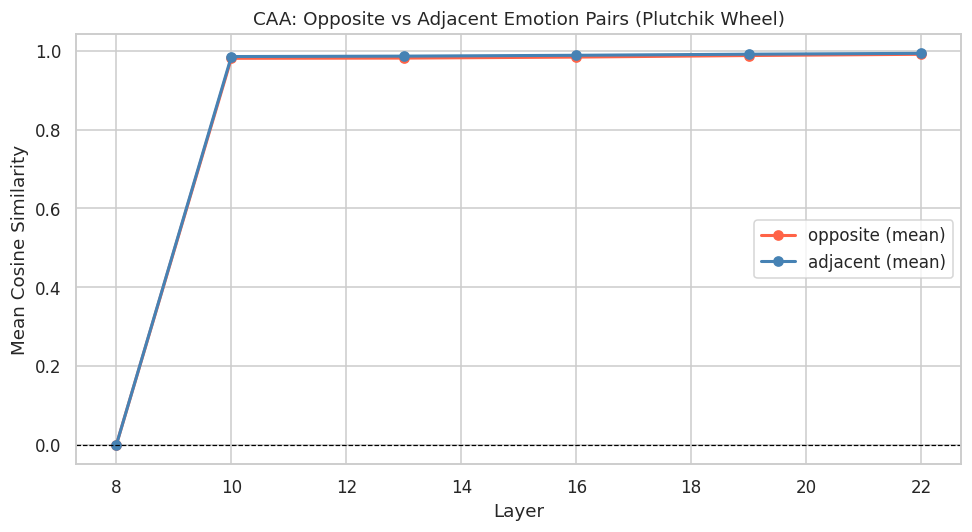

In [8]:
# Plot: opposite vs adjacent cosine over layers
fig, ax = plt.subplots(figsize=(9, 5))

for pair_type, color in [('opposite', 'tomato'), ('adjacent', 'steelblue')]:
    sub = df_pairs[df_pairs['type'] == pair_type]
    mean_by_layer = sub.groupby('layer')['cosine'].mean()
    ax.plot(mean_by_layer.index, mean_by_layer.values,
            marker='o', label=f'{pair_type} (mean)', color=color, linewidth=2)

ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
ax.set_xlabel('Layer')
ax.set_ylabel('Mean Cosine Similarity')
ax.set_title('CAA: Opposite vs Adjacent Emotion Pairs (Plutchik Wheel)')
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / 'caa_plutchik_pairs_by_layer.png', bbox_inches='tight')
plt.show()

df_pairs.to_csv(OUT_DIR / 'caa_plutchik_pairs.csv', index=False)

---
## 4. 2D/3D 可視化 — 感情方向の配置は連続的か？

8感情のCAAベクトルをPCAで2次元・3次元に射影し、感情間の配置を可視化する。
- 感情が**円状・連続的に分布**しているなら仮説支持
- 感情が**クラスタを形成して離れている**なら離散カテゴリ説を支持

Top-3 EVR: 0.429, 0.241, 0.140  (sum=0.809)


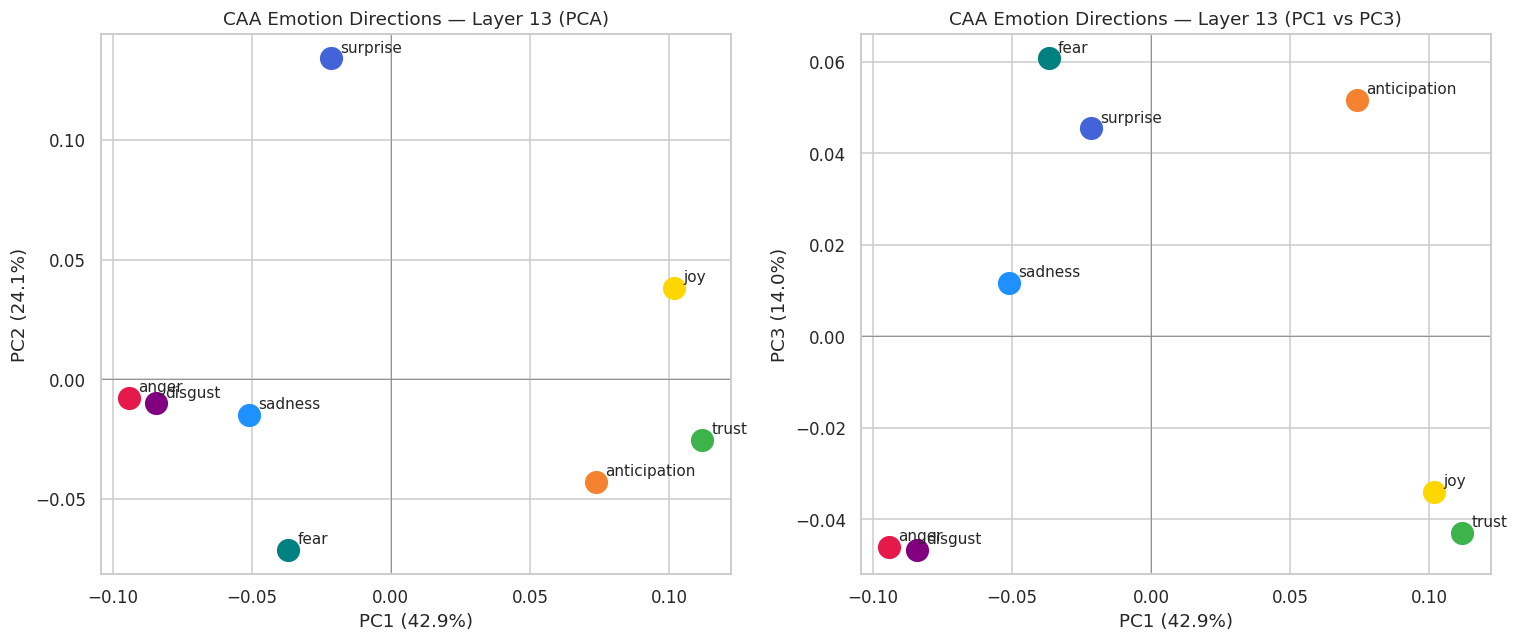

In [9]:
V = get_pooled(PRIMARY_LAYER)  # (8, 4096)

# PCA projection
pca = PCA(n_components=3)
V2  = pca.fit_transform(V)     # (8, 3)
evr = pca.explained_variance_ratio_

print(f'Top-3 EVR: {evr[0]:.3f}, {evr[1]:.3f}, {evr[2]:.3f}  (sum={evr[:3].sum():.3f})')

# Plutchik color wheel (approximate)
EMO_COLORS = {
    'joy':          '#FFD700',
    'trust':        '#3cb44b',
    'fear':         '#008080',
    'surprise':     '#4363d8',
    'sadness':      '#1e90ff',
    'disgust':      '#800080',
    'anger':        '#e6194b',
    'anticipation': '#f58231',
}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# PC1 vs PC2
ax = axes[0]
for i, emo in enumerate(EMOTION_ORDER):
    c = EMO_COLORS.get(emo, 'gray')
    ax.scatter(V2[i, 0], V2[i, 1], s=200, color=c, zorder=3)
    ax.annotate(emo, (V2[i, 0], V2[i, 1]),
                textcoords='offset points', xytext=(6, 4), fontsize=10)

# Draw arrows from origin to each emotion direction (showing direction, not just position)
ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.5)
ax.set_xlabel(f'PC1 ({evr[0]:.1%})')
ax.set_ylabel(f'PC2 ({evr[1]:.1%})')
ax.set_title(f'CAA Emotion Directions — Layer {PRIMARY_LAYER} (PCA)')

# PC1 vs PC3
ax = axes[1]
for i, emo in enumerate(EMOTION_ORDER):
    c = EMO_COLORS.get(emo, 'gray')
    ax.scatter(V2[i, 0], V2[i, 2], s=200, color=c, zorder=3)
    ax.annotate(emo, (V2[i, 0], V2[i, 2]),
                textcoords='offset points', xytext=(6, 4), fontsize=10)
ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.5)
ax.set_xlabel(f'PC1 ({evr[0]:.1%})')
ax.set_ylabel(f'PC3 ({evr[2]:.1%})')
ax.set_title(f'CAA Emotion Directions — Layer {PRIMARY_LAYER} (PC1 vs PC3)')

plt.tight_layout()
plt.savefig(OUT_DIR / f'caa_pca_2d_L{PRIMARY_LAYER}.png', bbox_inches='tight')
plt.show()

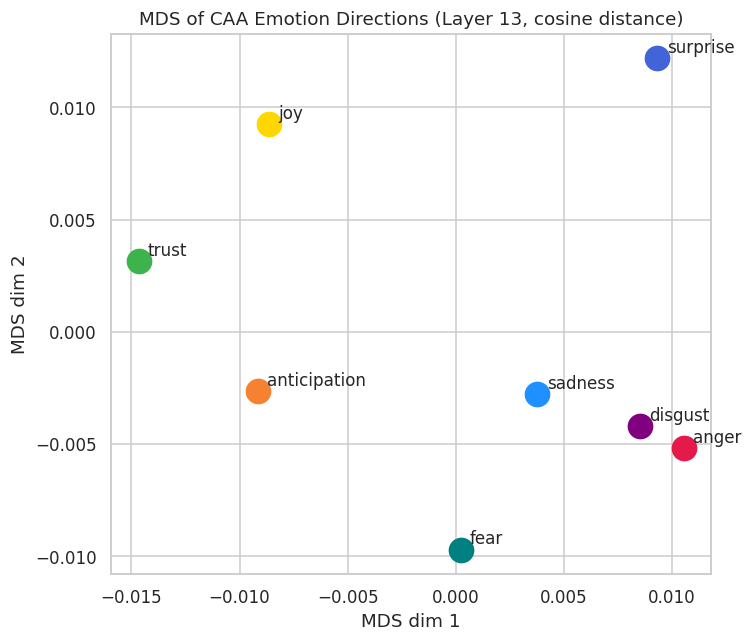

In [10]:
# MDS on 1 - cosine_similarity as distance
cos_mat    = cosine_matrix(V)
dist_mat   = np.clip(1 - cos_mat, 0, 2)  # cosine distance in [0, 2]
np.fill_diagonal(dist_mat, 0)

mds = MDS(n_components=2, dissimilarity='precomputed', random_state=0, n_init=8)
V_mds = mds.fit_transform(dist_mat)  # (8, 2)

fig, ax = plt.subplots(figsize=(7, 6))
for i, emo in enumerate(EMOTION_ORDER):
    c = EMO_COLORS.get(emo, 'gray')
    ax.scatter(V_mds[i, 0], V_mds[i, 1], s=250, color=c, zorder=3)
    ax.annotate(emo, (V_mds[i, 0], V_mds[i, 1]),
                textcoords='offset points', xytext=(6, 4), fontsize=11)

ax.set_title(f'MDS of CAA Emotion Directions (Layer {PRIMARY_LAYER}, cosine distance)')
ax.set_xlabel('MDS dim 1')
ax.set_ylabel('MDS dim 2')
plt.tight_layout()
plt.savefig(OUT_DIR / f'caa_mds_L{PRIMARY_LAYER}.png', bbox_inches='tight')
plt.show()

---
## 5. 強度別CAAベクトルの整合性

各感情について low/medium/high 強度の CAA ベクトルが同じ方向を向いているか確認する。
整合性が高いほど、「感情の方向」は強度に依存しない安定した軸であることを示す。

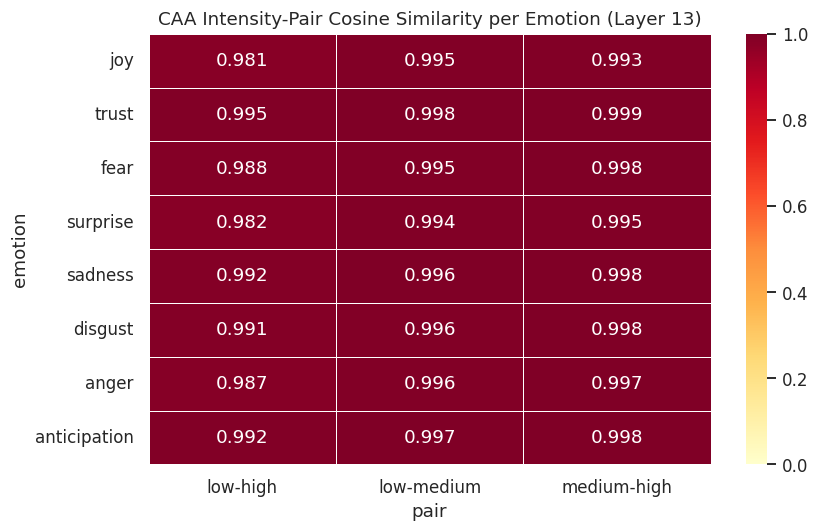


Mean cos(low-high) per emotion at layer 13
emotion
joy             0.981109
surprise        0.981821
anger           0.986778
fear            0.988308
disgust         0.990546
sadness         0.991629
anticipation    0.992403
trust           0.995067
Name: low-high, dtype: float64


In [11]:
INT_PAIRS = [(0, 1), (0, 2), (1, 2)]  # (low,med), (low,high), (med,high)
INT_LABELS = [(INTENSITY_ORDER[a], INTENSITY_ORDER[b]) for a, b in INT_PAIRS]

rows_int = []
for layer in LAYER_INDICES:
    V_int = get_caa(layer)  # (8, 3, 4096) unit-normed
    for e, emo in enumerate(EMOTION_ORDER):
        for (ia, ib), (la, lb) in zip(INT_PAIRS, INT_LABELS):
            cos = float(V_int[e, ia] @ V_int[e, ib])  # both unit-normed
            rows_int.append({
                'layer': layer, 'emotion': emo,
                'pair': f'{la}-{lb}', 'cosine': cos,
            })

df_int = pd.DataFrame(rows_int)

# Heatmap: emotion × intensity-pair at primary layer
pivot = df_int[df_int['layer'] == PRIMARY_LAYER].pivot(index='emotion', columns='pair', values='cosine')
pivot = pivot.loc[EMOTION_ORDER]

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlOrRd',
            vmin=0, vmax=1, ax=ax, linewidths=0.5)
ax.set_title(f'CAA Intensity-Pair Cosine Similarity per Emotion (Layer {PRIMARY_LAYER})')
plt.tight_layout()
plt.savefig(OUT_DIR / f'caa_intensity_consistency_L{PRIMARY_LAYER}.png', bbox_inches='tight')
plt.show()

print('\nMean cos(low-high) per emotion at layer', PRIMARY_LAYER)
print(pivot['low-high'].sort_values())

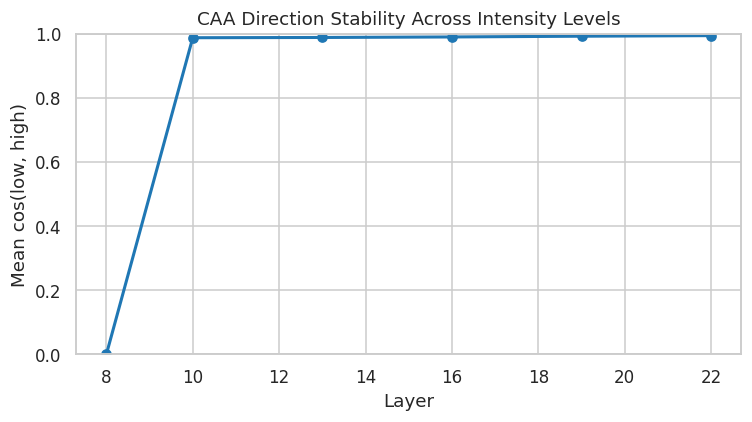

In [12]:
# Layer evolution of mean intensity consistency
mean_lh = (df_int[df_int['pair'] == 'low-high']
           .groupby('layer')['cosine'].mean())

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(mean_lh.index, mean_lh.values, marker='o', linewidth=2)
ax.set_xlabel('Layer')
ax.set_ylabel('Mean cos(low, high)')
ax.set_title('CAA Direction Stability Across Intensity Levels')
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig(OUT_DIR / 'caa_intensity_stability_by_layer.png', bbox_inches='tight')
plt.show()

df_int.to_csv(OUT_DIR / 'caa_intensity_consistency.csv', index=False)

---
## 6. レイヤー別の幾何学的構造の変化

CAAベクトルの幾何学的構造（コサイン類似度、参加比率）がレイヤーを通じてどのように発展するかを追う。
「感情空間の低次元化」が中間レイヤーで急激に起きるなら、感情表現の獲得層が特定できる。

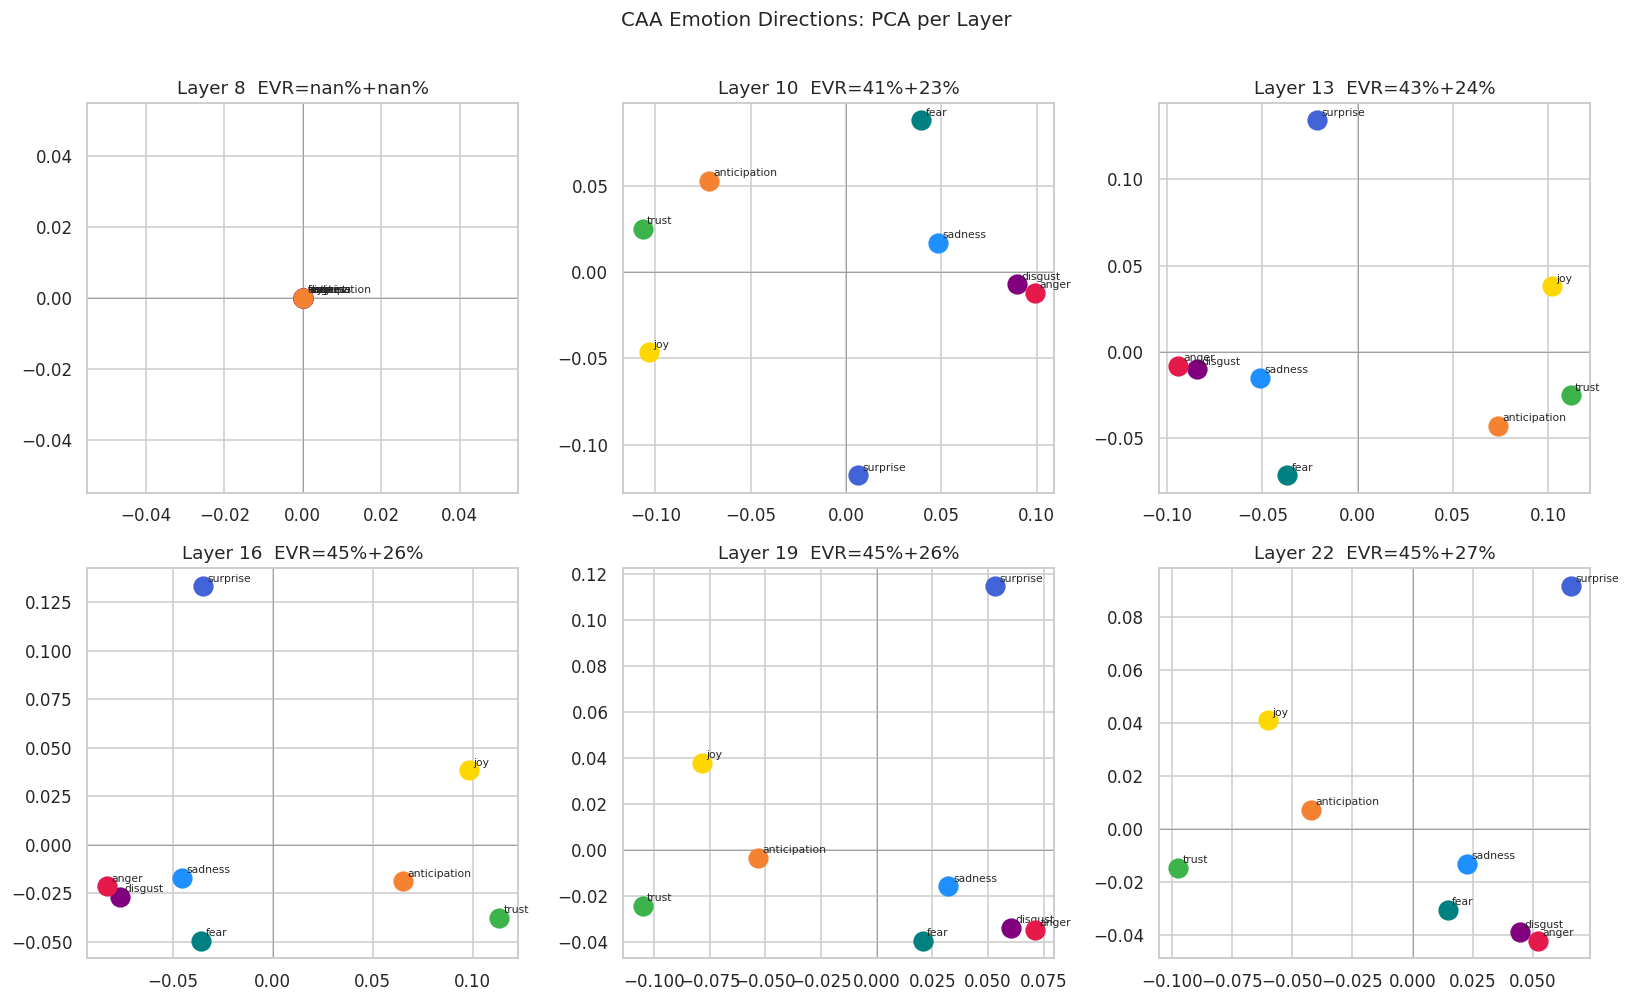

In [13]:
# Layer-wise PC1/PC2 loading comparison — does the axis rotate?
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, layer in zip(axes.flat, LAYER_INDICES):
    V = get_pooled(layer)
    pca = PCA(n_components=2)
    V2  = pca.fit_transform(V)
    evr = pca.explained_variance_ratio_
    for i, emo in enumerate(EMOTION_ORDER):
        c = EMO_COLORS.get(emo, 'gray')
        ax.scatter(V2[i, 0], V2[i, 1], s=150, color=c, zorder=3)
        ax.annotate(emo, (V2[i, 0], V2[i, 1]),
                    textcoords='offset points', xytext=(3, 3), fontsize=7)
    ax.axhline(0, color='gray', linewidth=0.4)
    ax.axvline(0, color='gray', linewidth=0.4)
    ax.set_title(f'Layer {layer}  EVR={evr[0]:.0%}+{evr[1]:.0%}')

plt.suptitle('CAA Emotion Directions: PCA per Layer', y=1.01, fontsize=13)
plt.tight_layout()
plt.savefig(OUT_DIR / 'caa_pca_all_layers.png', bbox_inches='tight')
plt.show()

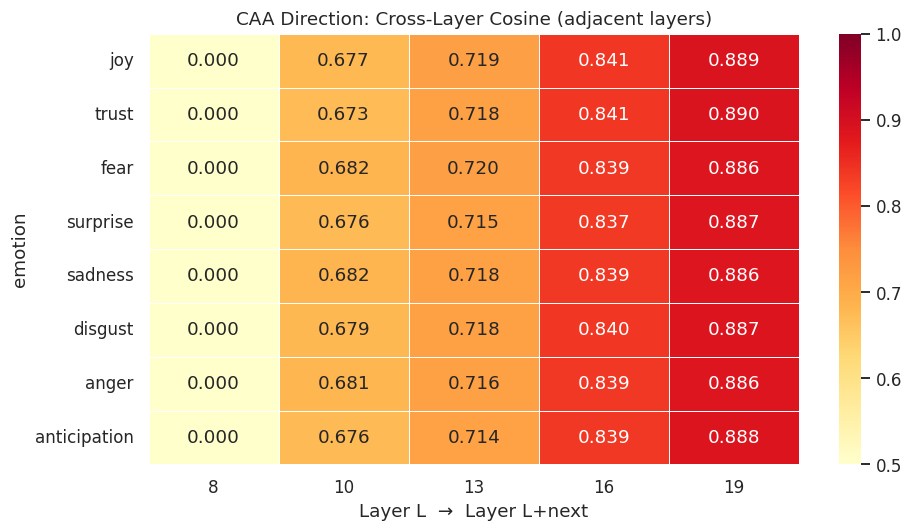

Done. Outputs saved to /home/maplesugano/proj/EmotionEngine_v2/analysis/caa/geometry


In [14]:
# Cross-layer alignment: how much do emotion directions change between adjacent layers?
layer_pairs = list(zip(LAYER_INDICES[:-1], LAYER_INDICES[1:]))
rows_cross = []
for l1, l2 in layer_pairs:
    V1 = get_pooled(l1)  # (8, 4096)
    V2 = get_pooled(l2)
    for e, emo in enumerate(EMOTION_ORDER):
        cos = float(V1[e] @ V2[e])  # unit-normed
        rows_cross.append({'from_layer': l1, 'to_layer': l2,
                           'emotion': emo, 'cosine': cos})

df_cross = pd.DataFrame(rows_cross)

pivot_cross = df_cross.pivot_table(
    values='cosine', index='emotion', columns='from_layer'
).reindex(EMOTION_ORDER)

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(pivot_cross, annot=True, fmt='.3f', cmap='YlOrRd',
            vmin=0.5, vmax=1, ax=ax, linewidths=0.5)
ax.set_title('CAA Direction: Cross-Layer Cosine (adjacent layers)')
ax.set_xlabel('Layer L  →  Layer L+next')
plt.tight_layout()
plt.savefig(OUT_DIR / 'caa_cross_layer_consistency.png', bbox_inches='tight')
plt.show()

df_cross.to_csv(OUT_DIR / 'caa_cross_layer_consistency.csv', index=False)
print('Done. Outputs saved to', OUT_DIR)